## Problem Statement

The goal of this project is to build a regression model that predicts the rating (Score) of an anime based on features like genre, number of episodes, popularity, and user engagement.

This helps in understanding what factors influence anime ratings.

In [1]:
import pandas as pd #panda is for handling data or tabels .....ofc we are taking csv file so we have to read it using this
import numpy as np #any kinf of calculation we do throught out the program depends on this ....or anything related to numbers

import matplotlib.pyplot as plt #this is just for making graphs and all

from sklearn.model_selection import train_test_split #this is to bifurcate the data into 80 percent supoose in training and 20 percent testing
from sklearn.preprocessing import LabelEncoder #ml models cant understand text so we convert everthing into numbers using label encoder
from sklearn.metrics import mean_squared_error, r2_score #meansqaure error and r2 score is basically used to understand the acuurcy of yout model
from sklearn.ensemble import RandomForestRegressor # this is the main model to used to predict continuos number of values which in here is our anime rating

In [2]:
df = pd.read_csv("/kaggle/input/datasets/gowrinair02/anime-dataset-2023-filtered/anime-dataset-2023-filtered.csv")  # upload your file in colab

df.head()

,anime_id,Name,Score,Genres,English name,Japanese name,sypnopsis,Type,Episodes,Aired,...,Duration,Rating,Ranked,Popularity,Members,Favorites,Watching,Completed,On-Hold,Dropped
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,"In the year 2071, humanity has colonized sever...",TV,26,"Apr 3, 1998 to Apr 24, 1999",...,24 min. per ep.,R - 17+ (violence & profanity),28.0,39,1251960,61971,105808,718161,71513,26678
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,"other day, another bounty—such is the life of ...",Movie,1,"Sep 1, 2001",...,1 hr. 55 min.,R - 17+ (violence & profanity),159.0,518,273145,1174,4143,208333,1935,770
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",Trigun,トライガン,"Vash the Stampede is the man with a $$60,000,0...",TV,26,"Apr 1, 1998 to Sep 30, 1998",...,24 min. per ep.,PG-13 - Teens 13 or older,266.0,201,558913,12944,29113,343492,25465,13925
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),ches are individuals with special powers like ...,TV,26,"Jul 2, 2002 to Dec 24, 2002",...,25 min. per ep.,PG-13 - Teens 13 or older,2481.0,1467,94683,587,4300,46165,5121,5378
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",Beet the Vandel Buster,冒険王ビィト,It is the dark century and the people are suff...,TV,52,"Sep 30, 2004 to Sep 29, 2005",...,23 min. per ep.,PG - Children,3710.0,4369,13224,18,642,7314,766,1108


## Dataset Description

The dataset contains information about anime such as:
- Name
- Genres
- Episodes
- Type
- Studios
- Popularity
- Score (Target Variable)

We will predict the Score using regression.

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14952 entries, 0 to 14951
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   anime_id       14952 non-null  int64  
 1   Name           14952 non-null  object 
 2   Score          14952 non-null  float64
 3   Genres         14952 non-null  object 
 4   English name   14952 non-null  object 
 5   Japanese name  14952 non-null  object 
 6   sypnopsis      13602 non-null  object 
 7   Type           14952 non-null  object 
 8   Episodes       14952 non-null  object 
 9   Aired          14952 non-null  object 
 10  Premiered      14952 non-null  object 
 11  Producers      14952 non-null  object 
 12  Licensors      14952 non-null  object 
 13  Studios        14952 non-null  object 
 14  Source         14952 non-null  object 
 15  Duration       14952 non-null  object 
 16  Rating         14952 non-null  object 
 17  Ranked         13231 non-null  float64
 18  Popula

,anime_id,Score,Ranked,Popularity,Members,Favorites,Watching,Completed,On-Hold,Dropped
count,14952.000000,14952.000000,13231.000000,14952.000000,1.495200e+04,14952.000000,14952.000000,1.495200e+04,14952.000000,14952.000000
mean,19017.432718,6.511526,6829.853828,7465.970907,4.068648e+04,537.629882,2619.806715,2.594310e+04,1121.307986,1377.861891
std,14588.758618,0.807185,4168.929475,4313.169381,1.348744e+05,4399.016449,15190.098642,9.812729e+04,4613.759597,5110.874501
min,1.000000,1.850000,1.000000,1.000000,2.000000e+02,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,4602.500000,6.080000,3309.500000,3732.000000,7.360000e+02,1.000000,27.000000,2.460000e+02,14.000000,48.000000
50%,16729.000000,6.510000,6618.000000,7466.500000,3.493500e+03,6.000000,127.000000,1.515500e+03,78.000000,102.000000
75%,33513.250000,7.010000,9942.000000,11194.000000,1.919325e+04,47.000000,723.000000,9.797000e+03,388.250000,377.000000
max,48492.000000,9.190000,15780.000000,17565.000000,2.589552e+06,183914.000000,887333.000000,2.182587e+06,187919.000000,174710.000000


## Data Cleaning

We remove unnecessary columns and handle missing values.
Columns like Name and Synopsis are removed because they are not useful for regression.

In [4]:
# Drop unnecessary columns
drop_cols = ['Name', 'English name', 'Japanese name', 'sypnopsis', 'Aired']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Handle missing values

df = df.ffill()

In [5]:
df.replace("Unknown", np.nan, inplace=True)

In [6]:
df.fillna(0, inplace=True)

In [7]:
df.drop('Premiered', axis=1, inplace=True)

In [8]:
df.drop('Producers', axis=1, inplace=True)

In [9]:
df.drop('Licensors', axis=1, inplace=True)

In [10]:
df.drop('Studios', axis=1, inplace=True)

In [11]:
df.drop('Duration', axis=1, inplace=True)

## Feature Engineering

Categorical columns like Genre, Type, Studios are converted into numerical values using Label Encoding.

In [12]:

le_type = LabelEncoder()
le_source = LabelEncoder()
le_rating = LabelEncoder()

df['Type'] = le_type.fit_transform(df['Type'].astype(str))
df['Source'] = le_source.fit_transform(df['Source'].astype(str))
df['Rating'] = le_rating.fit_transform(df['Rating'].astype(str))


In [13]:
df['Genres'] = df['Genres'].str.split(', ')

In [14]:
df['Genres'] = df['Genres'].apply(lambda x: x if isinstance(x, list) else [])

In [15]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df['Genres'])

In [16]:
genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_)

In [17]:
df = df.drop('Genres', axis=1)
df = pd.concat([df, genre_df], axis=1)

## Feature Selection

The target variable is Score.
All other columns are used as input features.

In [18]:
X = df.drop(columns=['Score'])
y = df['Score']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Used

We use Random Forest Regressor because it handles non-linear relationships well and gives good accuracy.

In [20]:
print(df.select_dtypes(include='object').columns)

Index(['Episodes'], dtype='object')


In [21]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [22]:
y_pred = model.predict(X_test)

## Evaluation Metrics

We evaluate the model using:
- RMSE (Root Mean Squared Error)
- R² Score

In [23]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.13642775799957896
R2 Score: 0.9713109376887014


## Conclusion

The regression model was able to predict anime ratings with reasonable accuracy.

We observed that features like popularity, members, and episodes influence the score.

Future improvements:
- Use advanced models like XGBoost
- Better encoding for Genres
- Feature selection

In [24]:
import matplotlib.pyplot as plt

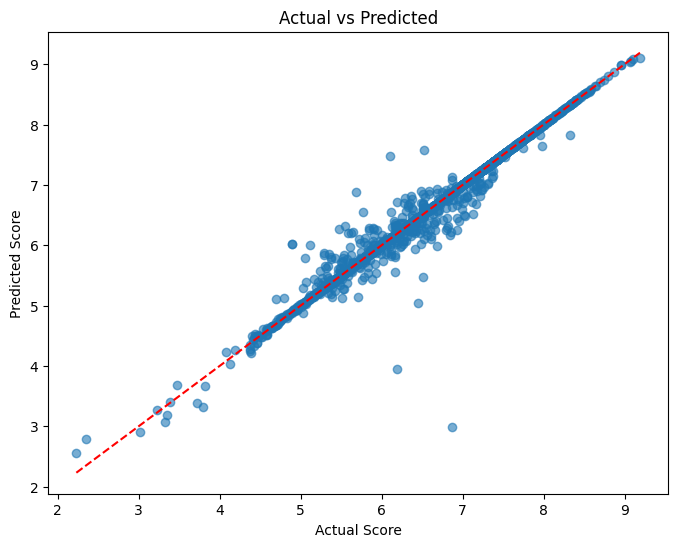

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted")
plt.show()

In [26]:
print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.13642775799957896
R2 Score: 0.9713109376887014


In [27]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(train_score, test_score)

0.996096862255405 0.9713109376887014


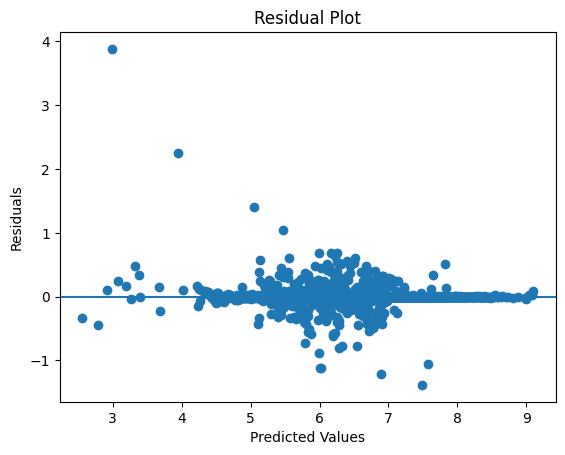

In [28]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

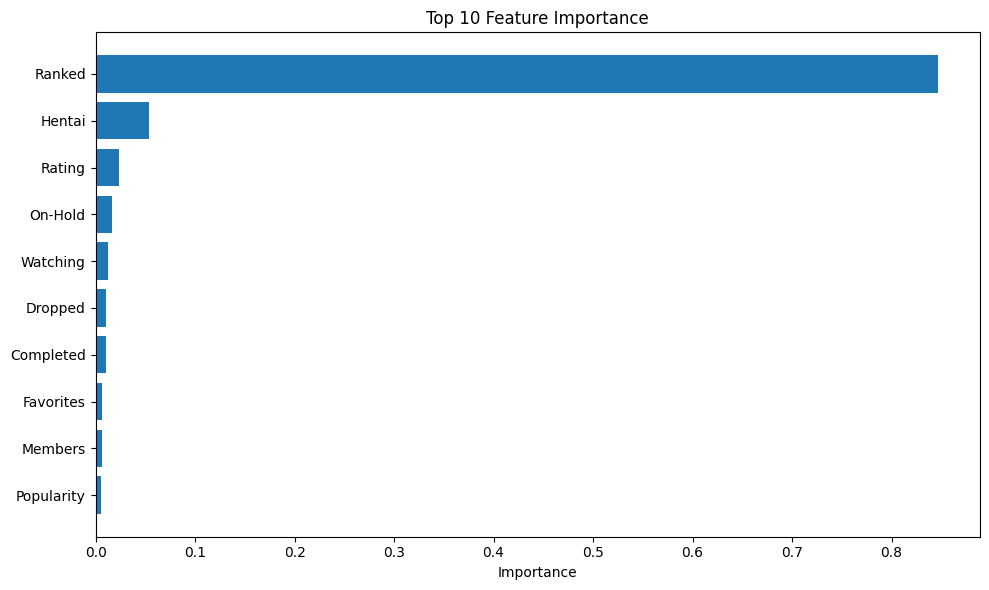

In [29]:
importances = model.feature_importances_
feat_names = X.columns

# Create dataframe
feat_imp = pd.DataFrame({
    'Feature': feat_names,
    'Importance': importances
})

# Sort
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

# Take top 10
top_features = feat_imp.head(10)

# Plot
plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [30]:
import joblib

joblib.dump(model, 'model.joblib')

['model.joblib']

In [31]:
import joblib

joblib.dump(le_type, 'le_type.joblib')
joblib.dump(le_source, 'le_source.joblib')
joblib.dump(le_rating, 'le_rating.joblib')

['le_rating.joblib']

In [32]:
import joblib
joblib.dump(mlb, 'mlb.joblib')

['mlb.joblib']

In [33]:
print(model.score(X_test, y_test))

0.9713109376887014


In [34]:
print(model.predict(X_test[:5]))
print(y_test[:5])

[6.2    7.6101 6.04   7.04   5.8842]
9532     6.20
9466     7.61
4720     6.04
4549     7.04
13400    5.90
Name: Score, dtype: float64
